In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00985-127787239.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00667-3846168829.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00891-3846169053.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00528-3846168690.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00689-3846168851.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00593-3846168755.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00894-3846169056.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00622-3846168784.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00907-3846169069.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00983-127787237.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00817-3846168979.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00576-3846168738.png
/kaggl

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn as sns 
import matplotlib.pyplot as plt

In [7]:
dataset_path = "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals"

In [11]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [16]:
import os
import cv2
data = []
labels = []

dataset_path = "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals"

for label, category in enumerate(["cat", "dog"]):
    folder = os.path.join(dataset_path, category)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (128, 128))

        data.append(img)
        labels.append(label)

X = np.array(data) / 255.0
y = np.array(labels)

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [45]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 395ms/step - accuracy: 0.6025 - loss: 0.7743 - val_accuracy: 0.7750 - val_loss: 0.5208
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 384ms/step - accuracy: 0.8438 - loss: 0.3740 - val_accuracy: 0.8550 - val_loss: 0.3538
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 385ms/step - accuracy: 0.9162 - loss: 0.2351 - val_accuracy: 0.8400 - val_loss: 0.3511
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 382ms/step - accuracy: 0.9563 - loss: 0.1488 - val_accuracy: 0.8750 - val_loss: 0.3165
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 379ms/step - accuracy: 0.9737 - loss: 0.0752 - val_accuracy: 0.8650 - val_loss: 0.3391
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 383ms/step - accuracy: 0.9900 - loss: 0.0444 - val_accuracy: 0.8700 - val_loss: 0.3666
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 379ms/step - accuracy: 0.9950 - loss: 0.0201 - val_accuracy: 0.8800 - val_loss: 0.3302


In [47]:
print("Test Accuracy:", model.evaluate(x_test, y_test)[1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8750 - loss: 0.3165
Test Accuracy: 0.875


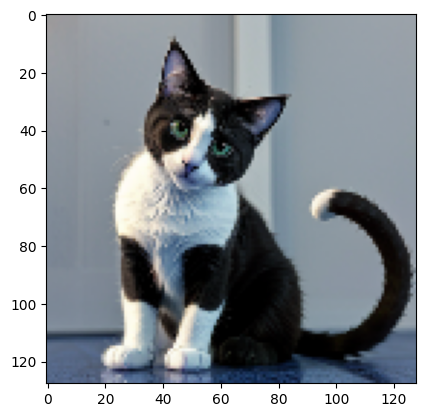

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Our model says it is: cat


In [52]:
idx2 = random.randint(0, len(y_test)-1)

plt.imshow(x_test[idx2])
plt.show()

img = x_test[idx2].reshape(1, x_test.shape[1], x_test.shape[2], x_test.shape[3])

y_pred = model.predict(img)
y_pred = (y_pred > 0.5).astype(int)

if y_pred[0][0] == 0:
    pred = "cat"
else:
    pred = "dog"

print("Our model says it is:", pred)